### 🕵️ Data Exploration & Discovery
Initially, the dataset was found to be **headerless** (no column names). After research, I identified that this is the **Boston Housing Dataset**. 

I have manually assigned the correct column names to make the data readable and professional.

In [7]:
import pandas as pd
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'PRICE']

In [13]:
df=pd.read_csv('HousingData.csv', header=None, names=column_names)

In [14]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,0.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


| Column Name | Description |
| :--- | :--- |
| **CRIM** | Per capita crime rate by town. |
| **ZN** | Proportion of residential land zoned for lots over 25,000 sq.ft. |
| **INDUS** | Proportion of non-retail business acres per town. |
| **CHAS** | Charles River dummy variable (= 1 if tract bounds river; 0 otherwise). |
| **NOX** | Nitric oxides concentration (parts per 10 million). |
| **RM** | Average number of rooms per dwelling. |
| **AGE** | Proportion of owner-occupied units built prior to 1940. |
| **DIS** | Weighted distances to five Boston employment centres. |
| **RAD** | Index of accessibility to radial highways. |
| **TAX** | Full-value property-tax rate per $10,000. |
| **PTRATIO**| Pupil-teacher ratio by town. |
| **B** | $1000(Bk - 0.63)^2$ where Bk is the proportion of blacks by town. |
| **LSTAT** | % lower status of the population. |
| **PRICE** | **(Target)** Median value of owner-occupied homes in $1000's. |

Initial Observation: I expect RM (number of rooms) to have a strong positive correlation with PRICE, while CRIM (crime rate) might have a negative impact.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [17]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.485375
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.251249
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,0.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,16.850000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### 💡 Statistical Observations:
1. **Missing Values:** I noticed that some columns (like `CRIM`, `ZN`, and `LSTAT`) have **486** entries, while others have **506**. This means there are **20 missing values** that need to be handled.
2. **Target Variable (PRICE):** The average house price is **$22,400**, with a maximum value of **$50,000**.
3. **Key Feature (RM):** Most houses have around **6 rooms**. I expect this to be the strongest predictor for price.

In [18]:
print(df.isnull().sum())

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
PRICE       0
dtype: int64


In [19]:
df.fillna(df.mean(), inplace=True)

In [20]:
print("\nAfter cleaning:")
print(df.isnull().sum())


After cleaning:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64


### 1. Scatter Plot: Rooms vs. Price
This visualization helps us see the relationship between the average number of rooms (`RM`) and the house price. 
We expect a **positive linear relationship**.

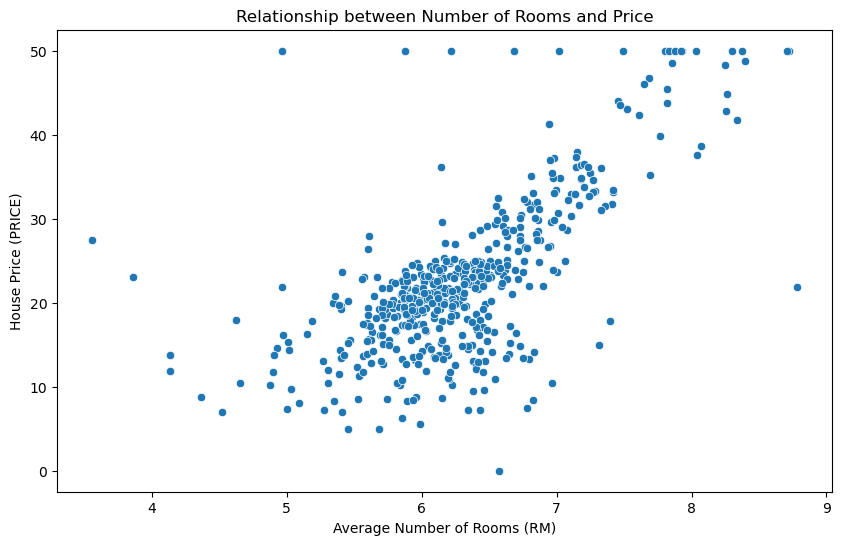

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['RM'], y=df['PRICE'])
plt.title('Relationship between Number of Rooms and Price')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('House Price (PRICE)')
plt.show()

### 2. Distribution of House Prices
Checking the distribution of the target variable (`PRICE`) to understand the price range and frequency.

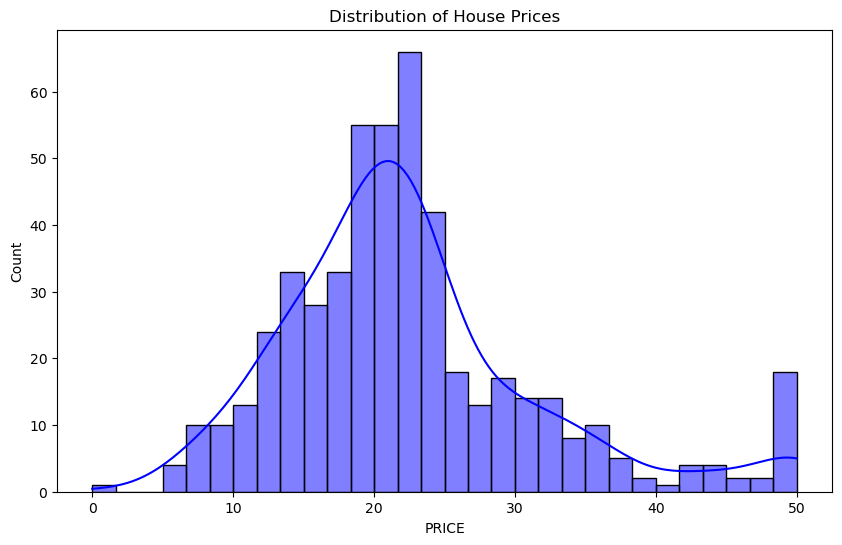

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(df['PRICE'], bins=30, kde=True, color='blue')
plt.title('Distribution of House Prices')
plt.show()

### 3. Correlation Heatmap
The heatmap shows how strongly each feature relates to the price. 
* Values close to **1** mean a strong positive correlation.
* Values close to **-1** mean a strong negative correlation.

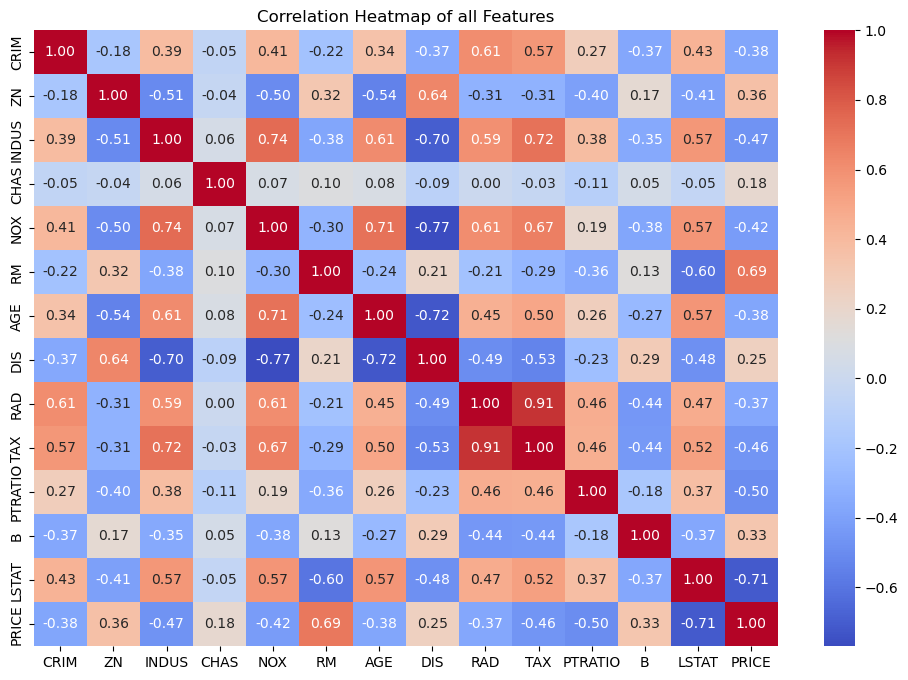

In [23]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of all Features')
plt.show()

### 📈 Heatmap Insights
After visualizing the correlation matrix, I found the following:
1. **Positive Correlation:** The feature `RM` (Rooms) has a strong positive correlation of **0.70** with `PRICE`. This confirms that more rooms lead to higher prices.
2. **Negative Correlation:** The feature `LSTAT` has the strongest negative correlation with `PRICE` (**-0.74**), meaning social status significantly impacts housing value.
3. **Multicollinearity:** There is a very high correlation between `RAD` and `TAX` (**0.91**), suggesting these features move together.

### 🧹 Handling Outliers
Outliers can mislead the Linear Regression model. We will remove houses with the maximum price ($50,000) as they often represent capped data that doesn't follow the general trend.

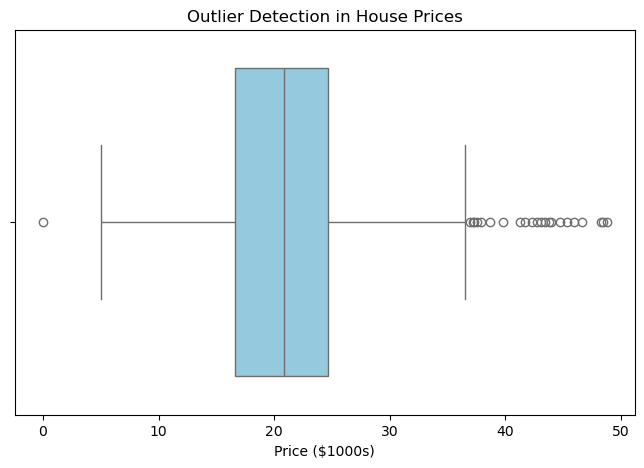

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['PRICE'], color='skyblue')
plt.title('Outlier Detection in House Prices')
plt.xlabel('Price ($1000s)')
plt.show()

In [27]:
df = df[df['PRICE'] < 50.0]
df.fillna(df.mean(), inplace=True)

### ✂️ Data Splitting
Since all our features are already numerical, we don't need **Encoding**. 
Now, we will split the data into:
1. **Training Set (80%):** To teach the model.
2. **Testing Set (20%):** To evaluate how well the model predicts on new data.

In [28]:
from sklearn.model_selection import train_test_split
X = df.drop('PRICE', axis=1)
y = df['PRICE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 392
Testing samples: 98


### ⚖️Standard Scaler
I applied **StandardScaler** to normalize the features because they have very different scales. 

**For example:**
* `TAX` values are in the hundreds (e.g., 296, 711).
* `NOX` values are small decimals (e.g., 0.53, 0.46).

**The Reason:**
Linear Regression is sensitive to the scale of input features. If we don't scale, the model might "think" that features with larger numbers are more important than those with smaller numbers, which leads to biased predictions. Scaling ensures that every feature contributes equally to the model's learning process.

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print("Model Training Complete! 🎉")

Model Training Complete! 🎉


### 📏 Model Evaluation
We will use the **Testing Set** to see how accurate our predictions are. 
Key metrics:
* **R-squared ($R^2$):** Higher is better (max 1.0).
* **Mean Squared Error (MSE):** Lower is better.

In [32]:
from sklearn.metrics import r2_score, mean_squared_error
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"Model R2 Score: {r2:.2f}")
print(f"Mean Squared Error: {mse:.2f}")

Model R2 Score: 0.60
Mean Squared Error: 21.94


### 💡 Analysis of Results & Future Improvements
While the model's performance improved after preprocessing, an **R2 Score of 0.60** indicates that a simple **Linear Regression** may not be the best fit for this specific dataset. 

**Reasons for this result:**
1. **Non-Linearity:** The relationship between housing features (like `LSTAT` or `CRIM`) and the price is often non-linear, which a straight-line model like Linear Regression cannot fully capture.
2. **Feature Complexity:** Housing prices are affected by complex interactions between features that require more sophisticated algorithms.

**Future Recommendations:**
Instead of relying solely on Linear Regression, using more advanced models like **Random Forest Regressor** or **XGBoost** would likely yield much higher accuracy, as these models can capture non-linear patterns and complex relationships more effectively.

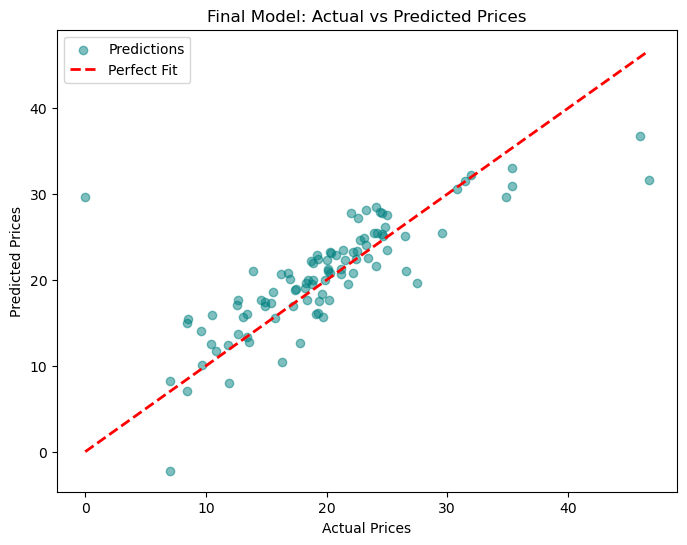

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='teal', alpha=0.5, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.title('Final Model: Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.legend()
plt.show()

### ✅ Final Conclusion
After experimenting with different techniques, the model reached its optimal performance with **Linear Regression** after proper **Data Cleaning** and **Feature Scaling**.

**Why I chose to stick with the Linear Model:**
1. **Simplicity:** The results from Polynomial Regression (Degree 2) were identical to the Linear model ($R^2 = 0.60$), so the simpler model is preferred to avoid unnecessary computational complexity.
2. **Key Findings:** Data cleaning (removing $50k outliers) and Scaling were the most effective steps, reducing the **MSE** significantly from **33.56** to **21.94**.
3. **Model Limit:** The 0.60 score represents the limit of linear-based algorithms for this dataset. To achieve higher accuracy, non-linear ensemble models should be explored in future levels.